# 🏦 Smart Loan Approval & Risk Assessment System

## Exploratory Data Analysis (EDA)

In this notebook, we will explore the loan approval dataset to understand its structure, identify data quality issues, analyze feature distributions, and gain insights before preprocessing and model development.

## Step 1: Import Libraries

Import the required libraries for data manipulation and visualization.

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


## Step 2: Load Dataset

Load the loan approval dataset into a Pandas DataFrame.

In [3]:
df = pd.read_csv("../data/raw/loan_approval_dataset.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Step 3: Display First Five Rows

Preview the dataset to understand its structure and available features.

In [4]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


## Step 4: Dataset Overview

Display the number of rows, columns, data types, and memory usage.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


## Step 5: Dataset Shape

Check the total number of rows and columns.

In [6]:
print(f"Number of Rows: {df.shape[0]}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 4269
Number of Columns: 13


## Step 6: Column Names

Display all feature names in the dataset.

In [7]:
df.columns

Index(['loan_id', ' no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='object')

## Step 7: Check Missing Values

Check whether the dataset contains any missing values.

Missing values can negatively affect machine learning models, so identifying them is an important step before preprocessing.

In [8]:
missing_values = df.isnull().sum()

print("Total Missing Values:", missing_values.sum())

missing_values[missing_values > 0]


Total Missing Values: 0


Series([], dtype: int64)

## Step 8: Check Duplicate Records

Duplicate records can introduce bias during model training.

Let's verify whether duplicate rows exist in the dataset.

In [9]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


## Step 9: Statistical Summary

Generate descriptive statistics for all numerical features to understand their distributions, ranges, and central tendencies.

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.472617e+06,6.503637e+06,-100000.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


## Step 10: Target Variable Distribution

Analyze the distribution of the target variable (`loan_status`).

Understanding class balance is important before training classification models.

In [11]:
df[" loan_status"].value_counts()

 loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

## Step 11: Visualize Target Distribution

Visualize the distribution of approved and rejected loans.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7712\2150167134.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=" loan_status", palette="Set2")


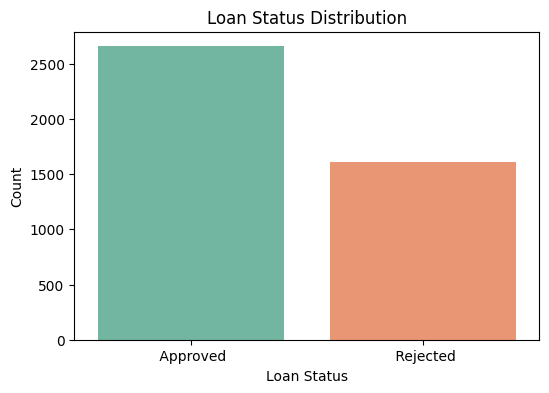

In [21]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x=" loan_status", palette="Set2")

plt.title("Loan Status Distribution")

plt.xlabel("Loan Status")

plt.ylabel("Count")

plt.savefig(
    "../screenshots/loan_status_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 12: Distribution of Numerical Features

Visualize the distribution of numerical features to understand their spread, skewness, and potential outliers.

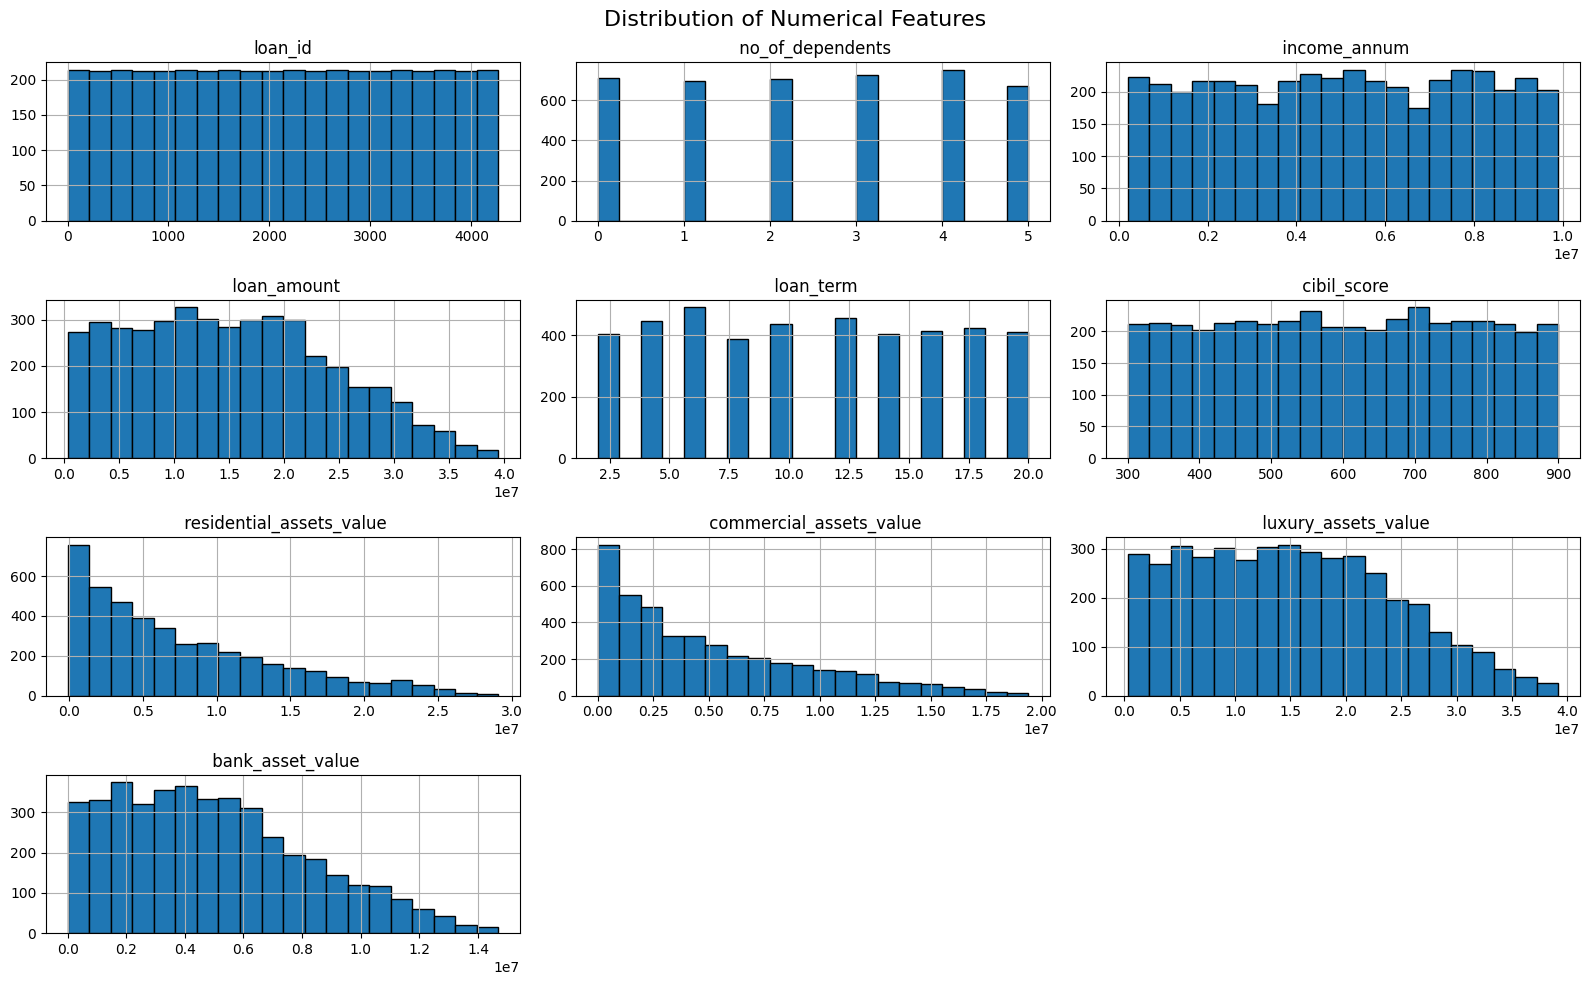

In [22]:
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_columns].hist(
    figsize=(16, 10),
    bins=20,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)

plt.tight_layout()

plt.savefig(
    "../screenshots/distribution_of_numerical_features.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 13: Boxplots for Numerical Features

Boxplots help identify outliers and understand the spread of numerical variables.

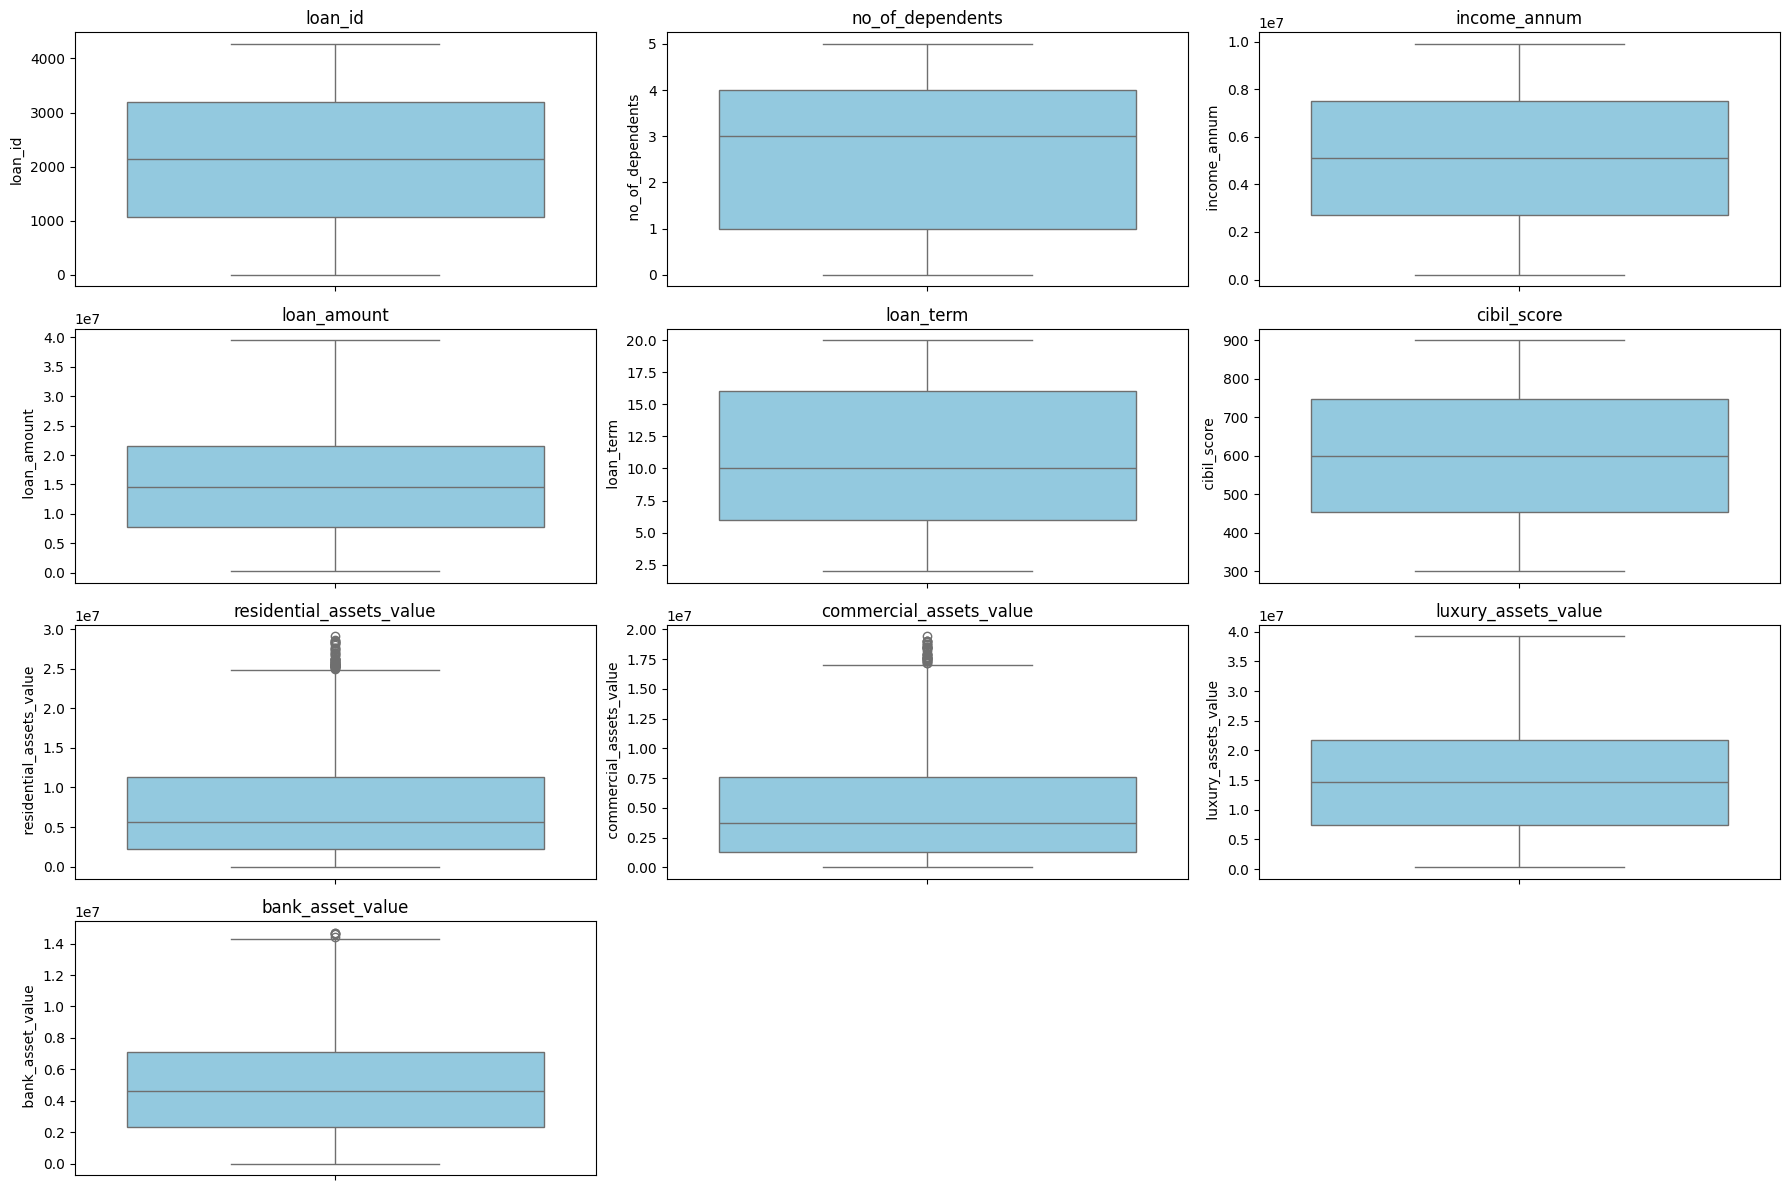

In [23]:
plt.figure(figsize=(18, 12))

for i, column in enumerate(numerical_columns, 1):
    plt.subplot(4, 3, i)

    sns.boxplot(y=df[column], color="skyblue")

    plt.title(column.strip())

plt.tight_layout()

plt.savefig(
    "../screenshots/boxplots.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 14: Correlation Matrix

Analyze relationships between numerical features using a correlation heatmap.

This helps identify highly correlated variables and potential redundancy.

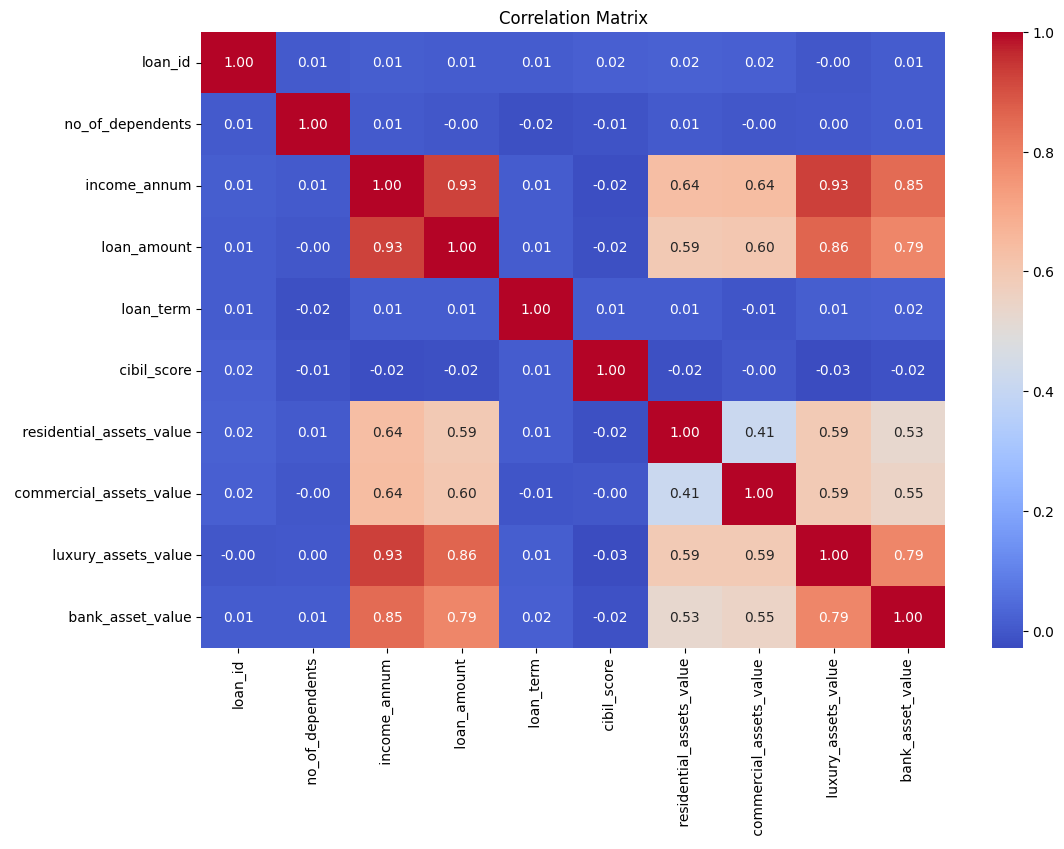

In [24]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.savefig(
    "../screenshots/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 15: Categorical Feature Distribution

Visualize the distribution of categorical variables.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7712\2627602504.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7712\2627602504.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7712\2627602504.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


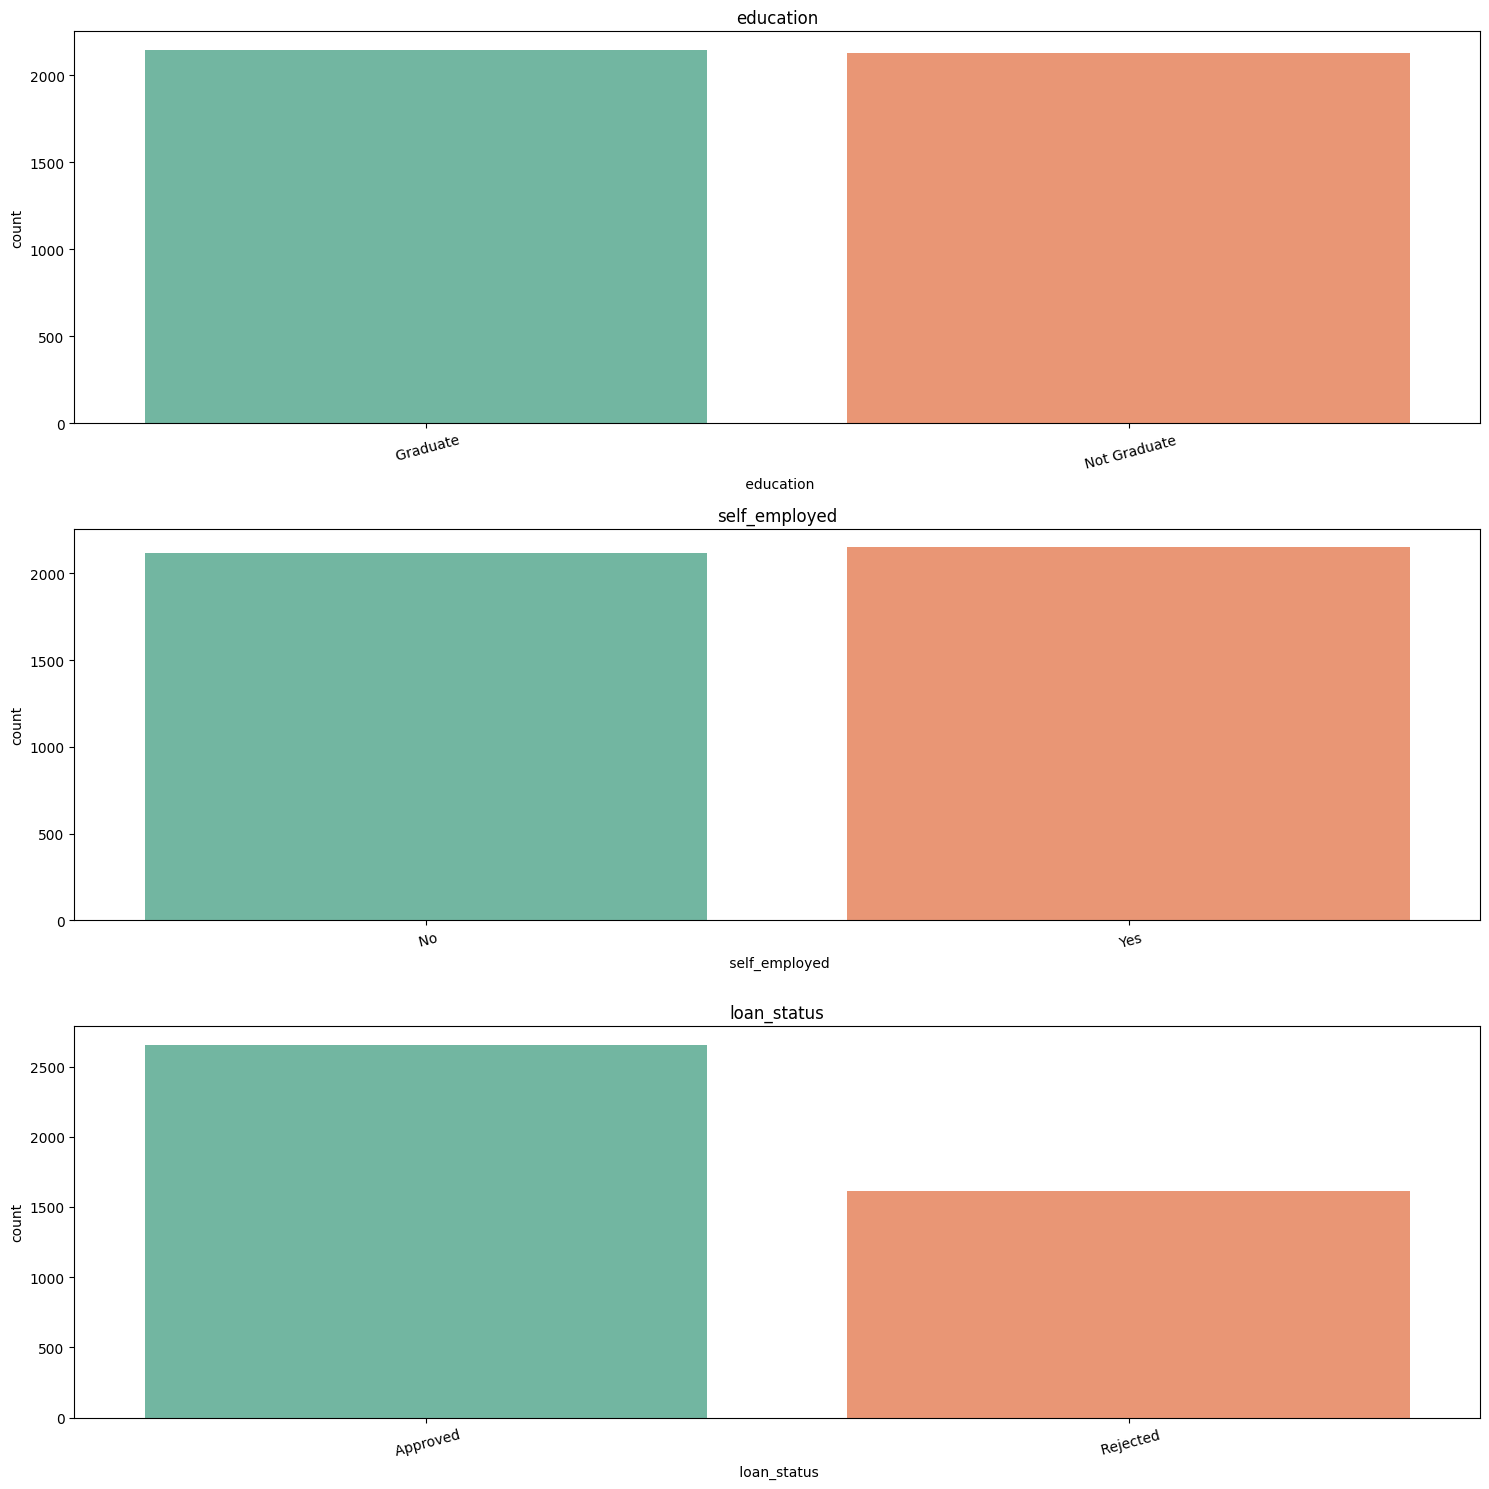

In [25]:
categorical_columns = df.select_dtypes(include="object").columns

plt.figure(figsize=(15, 5 * len(categorical_columns)))

for i, column in enumerate(categorical_columns, 1):
    plt.subplot(len(categorical_columns), 1, i)

    sns.countplot(
        data=df,
        x=column,
        palette="Set2"
    )

    plt.title(column.strip())

    plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../screenshots/categorical_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Step 16: Loan Status vs Categorical Features

Analyze how categorical variables relate to the loan approval outcome.

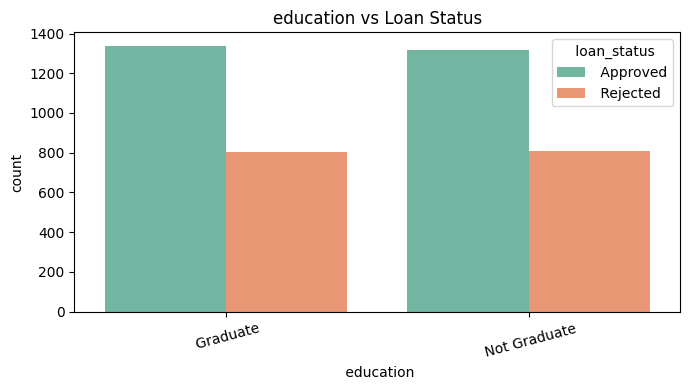

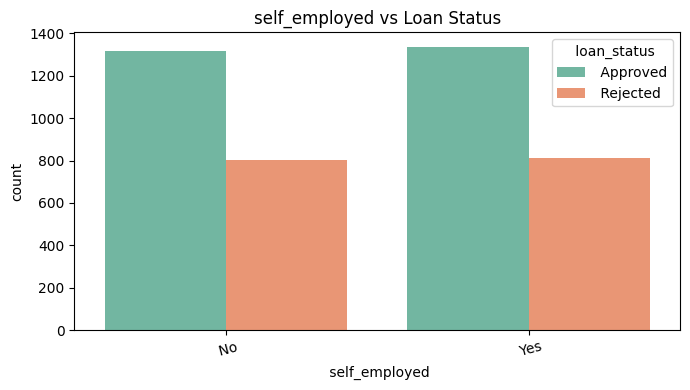

In [28]:
for column in categorical_columns:
    if column.strip() != "loan_status":

        plt.figure(figsize=(7, 4))

        sns.countplot(
            data=df,
            x=column,
            hue=" loan_status",
            palette="Set2"
        )

        plt.title(f"{column.strip()} vs Loan Status")

        plt.xticks(rotation=15)

        plt.tight_layout()

        plt.savefig(
            f"../screenshots/{column.strip()}_vs_loan_status.png",
            dpi=300,
            bbox_inches="tight"
        )

        plt.show()

# Step 17: Key Findings

## Dataset Summary

- Dataset contains 4,269 loan applications.
- No missing values were found.
- No duplicate records were present.
- Loan approval classes are slightly imbalanced (Approved > Rejected).
- Numerical financial features contain natural right-skewed distributions.
- Several asset-related features contain high-value outliers that represent genuine customer information.
- Strong positive correlations exist between annual income, loan amount, and asset values.
- Education and self-employment status alone do not significantly affect loan approval.

## Business Insights

- Customers with higher annual income generally receive larger loans.
- Asset ownership strongly reflects borrowing capacity.
- Credit history (CIBIL Score) is expected to play a major role during model training.
- Outliers should be retained because they represent valid high-net-worth customers.
- This dataset is clean and suitable for predictive modeling without extensive preprocessing.

# Step 19: Conclusion

The exploratory data analysis indicates that the dataset is clean, balanced, and well-structured for a binary classification problem.

Financial variables such as annual income, loan amount, and asset values exhibit meaningful relationships that are expected in real-world banking scenarios.

The absence of missing values and duplicate records reduces preprocessing complexity, allowing the focus to shift toward feature engineering and model optimization in the next stage.